In [ ]:
!pip install pyarrow

Training Dataset:
        dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0  0.121478   tcp       -   FIN      6      4     258     172  74.087486   
1  0.649902   tcp       -   FIN     14     38     734   42014  78.473373   
2  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4  0.449454   tcp       -   FIN     10      6     534     268  33.373825   

          sload  ...  trans_depth  response_body_len  ct_src_dport_ltm  \
0  14158.942383  ...            0                  0                 1   
1   8395.112305  ...            0                  0                 1   
2   1572.271851  ...            0                  0                 1   
3   2740.178955  ...            0                  0                 1   
4   8561.499023  ...            0                  0                 2   

   ct_dst_sport_ltm  is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  \
0            

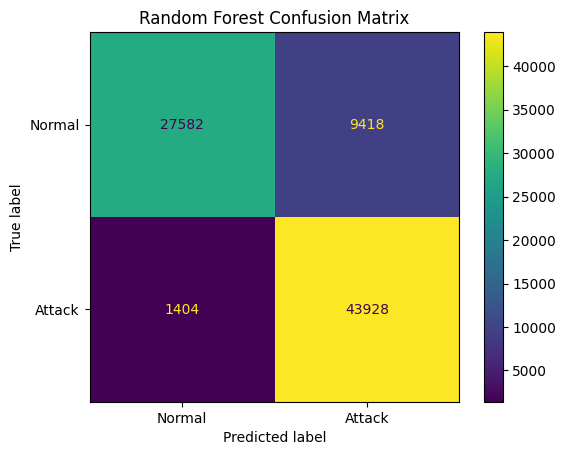


Feature Importance:
sload                0.097842
dload                0.083666
rate                 0.074338
tcprtt               0.070907
ackdat               0.067877
dmean                0.066671
sbytes               0.055505
smean                0.054934
dinpkt               0.053103
dur                  0.049289
synack               0.042826
sinpkt               0.042730
dbytes               0.042282
dpkts                0.027903
ct_dst_sport_ltm     0.022920
sjit                 0.020815
ct_src_dport_ltm     0.018630
dloss                0.017516
djit                 0.017443
spkts                0.015565
sloss                0.010033
dtcpb                0.009362
stcpb                0.008386
is_sm_ips_ports      0.007601
swin                 0.006286
trans_depth          0.005763
ct_flw_http_mthd     0.005144
response_body_len    0.003898
dwin                 0.000460
is_ftp_login         0.000173
ct_ftp_cmd           0.000131
dtype: float64


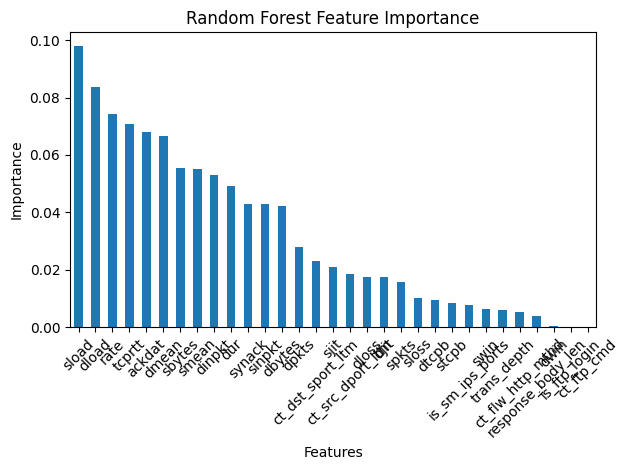

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


train_data = pd.read_parquet("UNSW_NB15_training-set.parquet")
test_data = pd.read_parquet("UNSW_NB15_testing-set.parquet")

print("Training Dataset:")
print(train_data.head())

print("\nTraining Dataset Shape:")
print(train_data.shape)

print("\nTesting Dataset Shape:")
print(test_data.shape)

print("\nAvailable Columns:")
print(train_data.columns.tolist())


numeric_columns = train_data.select_dtypes(include="number").columns.tolist()

features = [
    column for column in numeric_columns
    if column.lower() not in ["label", "id"]
]

print("\nSelected Numerical Features:")
print(features)

X_train = train_data[features].copy()
X_test = test_data[features].copy()

y_train = train_data["label"].copy()
y_test = test_data["label"].copy()

print("\nTraining Features Shape:")
print(X_train.shape)

print("\nTesting Features Shape:")
print(X_test.shape)

print("\nTarget Classes:")
print(y_train.value_counts())

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

X_train = X_train.replace([float("inf"), float("-inf")], pd.NA)
X_test = X_test.replace([float("inf"), float("-inf")], pd.NA)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print("\nMissing Values in Training Data:")
print(X_train.isnull().sum().sum())

print("\nMissing Values in Testing Data:")
print(X_test.isnull().sum().sum())

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("\nRandom Forest Model Trained Successfully.")

y_pred = model.predict(X_test)

print("\nPredictions Completed.")

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)


importance.plot(
    kind="bar",
    title="Random Forest Feature Importance"
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
'''Result: The Random Forest ensemble learning algorithm was
 successfully implemented on the UNSW-NB15 dataset.
  The model classified network traffic into Normal
   and Attack classes with an accuracy of 86.86%.
   The model achieved an F1-score of 0.89 for Attack traffic,
   indicating effective identification of malicious network traffic.
   The confusion matrix and feature-importance analysis were also generated
   to evaluate the model's classification performance.'''